# Stock Price Prediction

## 1. Get the data

In [1]:
import os

FILE = 'Test_Trading.xlsx'
if not os.path.exists(FILE):
    from google.colab import files
    uploaded = files.upload()          # choose Test_Trading.xlsx
    FILE = list(uploaded.keys())[0]

print('Using file:', FILE)

Saving Test_Trading.xlsx to Test_Trading.xlsx
Using file: Test_Trading.xlsx


## 2. Imports

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

## 3. Read the data

The sheet has 5 stock blocks side by side (`Closing Price | Return Rate | Units`), then portfolio columns and a summary table at the bottom. We reshape it into one tidy table: **Date, Stock, Close, Units**.

In [3]:
raw = pd.read_excel(FILE, header=None)

# row 0 = stock names, row 1 = column labels; each stock block starts at its 'Closing Price' column
stock_cols = {raw.iloc[0, c]: c for c in range(1, raw.shape[1]) if raw.iloc[1, c] == 'Closing Price'}
print(stock_cols)

dates = pd.to_datetime(raw.iloc[2:, 0], errors='coerce')
valid = dates.notna() & (dates > '2000-01-01')      # keeps only real date rows (drops the summary table at the bottom)

frames = []
for name, c in stock_cols.items():
    part = pd.DataFrame({
        'Date':  dates[valid],
        'Stock': name,
        'Close': pd.to_numeric(raw.iloc[2:, c][valid], errors='coerce'),
        'Units': pd.to_numeric(raw.iloc[2:, c + 2][valid], errors='coerce'),
    })
    frames.append(part.dropna(subset=['Close']))

df = pd.concat(frames).sort_values(['Stock', 'Date']).reset_index(drop=True)
df

{'Adani Power Ltd': 1, 'Sun Pharmaceutical Industries Ltd': 4, 'Coal India Limited': 7, 'Infosys Ltd': 10, 'ideaForge Technology Ltd': 13}


,Date,Stock,Close,Units
0,2026-02-17,Adani Power Ltd,144.35,49.0
1,2026-02-18,Adani Power Ltd,144.49,49.0
2,2026-02-19,Adani Power Ltd,140.45,49.0
3,2026-02-20,Adani Power Ltd,142.70,49.0
4,2026-02-23,Adani Power Ltd,144.05,49.0
...,...,...,...,...
589,2026-04-09,ideaForge Technology Ltd,429.85,40.0
590,2026-04-10,ideaForge Technology Ltd,436.65,40.0
591,2026-04-11,ideaForge Technology Ltd,438.80,40.0
592,2026-04-14,ideaForge Technology Ltd,457.10,40.0


In [4]:
df.shape

(594, 4)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594 entries, 0 to 593
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    594 non-null    datetime64[ns]
 1   Stock   594 non-null    object        
 2   Close   594 non-null    float64       
 3   Units   594 non-null    float64       
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 18.7+ KB


In [6]:
df.describe()

,Date,Close,Units
count,594,594.000000,594.000000
mean,2026-05-26 19:16:21.818181632,882.248737,33.915825
min,2026-02-17 00:00:00,137.820000,15.000000
25%,2026-04-02 00:00:00,401.150000,20.000000
50%,2026-05-26 00:00:00,463.750000,40.000000
75%,2026-07-18 00:00:00,1317.775000,49.000000
max,2026-09-09 00:00:00,2001.100000,50.000000
std,NaN,638.201551,15.671899


In [7]:
df.isnull().sum()

,0
Date,0
Stock,0
Close,0
Units,0


In [8]:
# rows and date range per stock
df.groupby('Stock')['Date'].agg(['min', 'max', 'count'])

,min,max,count
Stock,,,
Adani Power Ltd,2026-02-17,2026-09-09,139
Coal India Limited,2026-02-17,2026-09-09,139
Infosys Ltd,2026-02-17,2026-09-09,139
Sun Pharmaceutical Industries Ltd,2026-02-17,2026-09-09,139
ideaForge Technology Ltd,2026-02-17,2026-04-16,38


> **Heads-up:** ideaForge has only ~38 rows and its data stops in April, so it is much thinner than the other four stocks. It is still used for training, but forecasts are only made for stocks with enough recent data (see step 13).

## 4. Feature engineering (new step for time series)

Prices alone can't predict tomorrow, so we build features from **past and current** prices only. **Target = next trading day's closing price.**

In [9]:
def make_features(g):
    """g = one stock's rows (Date, Stock, Close). Uses only current/past prices, so no future leakage."""
    g = g[['Date', 'Stock', 'Close']].sort_values('Date').copy()
    g['ret_1'] = g['Close'].pct_change()
    for k in (1, 2, 3, 5):
        g[f'lag_{k}'] = g['Close'].shift(k)
    g['ma_5'] = g['Close'].rolling(5).mean()
    g['ma_10'] = g['Close'].rolling(10).mean()
    g['vol_5'] = g['ret_1'].rolling(5).std()
    g['day_of_week'] = g['Date'].dt.dayofweek
    g['month'] = g['Date'].dt.month
    return g

feat = pd.concat([make_features(g) for _, g in df.groupby('Stock')], ignore_index=True)
feat['Next_Close'] = feat.groupby('Stock')['Close'].shift(-1)      # TARGET
feat['Next_Date'] = feat.groupby('Stock')['Date'].shift(-1)        # date of the target (used for plots only)

# drop rows with missing lags / no next day; sort by date so the split below is chronological
data = feat.dropna().sort_values(['Date', 'Stock']).reset_index(drop=True)
data

,Date,Stock,Close,ret_1,lag_1,lag_2,lag_3,lag_5,ma_5,ma_10,vol_5,day_of_week,month,Next_Close,Next_Date
0,2026-03-02,Adani Power Ltd,137.97,-0.015274,140.11,141.34,140.54,144.05,140.854,142.031,0.012886,0,3,137.82,2026-03-04
1,2026-03-02,Coal India Limited,426.25,-0.010217,430.65,433.50,438.60,426.00,431.990,426.520,0.013535,0,3,449.40,2026-03-04
2,2026-03-02,Infosys Ltd,1288.90,-0.008615,1300.10,1289.10,1290.10,1327.50,1288.740,1325.980,0.020308,0,3,1306.10,2026-03-04
3,2026-03-02,Sun Pharmaceutical Industries Ltd,1752.50,0.008923,1737.00,1785.70,1764.20,1732.30,1754.240,1738.280,0.017972,0,3,1750.50,2026-03-04
4,2026-03-02,ideaForge Technology Ltd,441.30,0.068523,413.00,424.60,409.90,409.45,419.540,416.485,0.037127,0,3,429.00,2026-03-04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
539,2026-09-05,Sun Pharmaceutical Industries Ltd,1895.00,-0.002106,1899.00,1916.00,1931.70,1984.80,1914.140,1921.030,0.011420,5,9,1885.90,2026-09-08
540,2026-09-08,Adani Power Ltd,208.40,0.019121,204.49,207.20,208.29,204.36,207.216,207.327,0.013778,1,9,214.90,2026-09-09
541,2026-09-08,Coal India Limited,420.25,0.003342,418.85,415.35,420.05,401.60,418.470,410.020,0.018997,1,9,431.00,2026-09-09
542,2026-09-08,Infosys Ltd,1082.00,-0.005057,1087.50,1130.00,1130.30,1156.00,1113.960,1123.440,0.014593,1,9,1035.00,2026-09-09


In [10]:
data.shape

(544, 15)

## 5. EDA

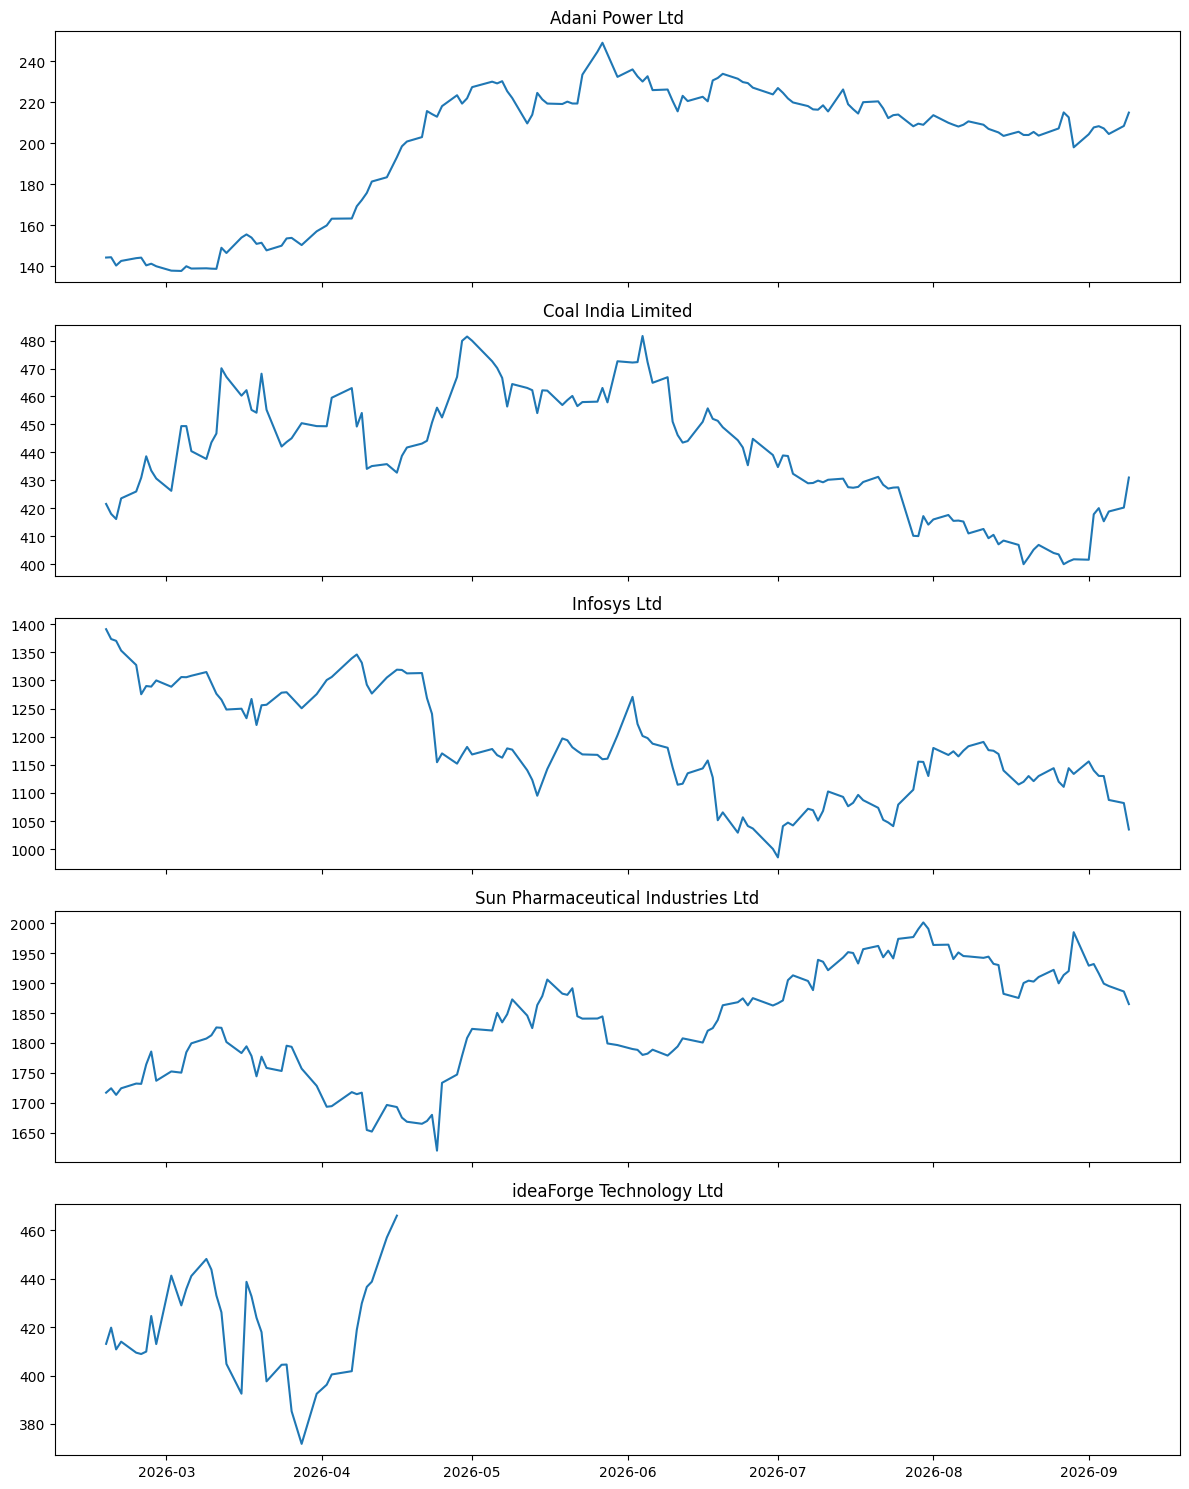

In [11]:
stocks = df['Stock'].unique()
fig, axes = plt.subplots(len(stocks), 1, figsize=(12, 3 * len(stocks)), sharex=True)
for ax, s in zip(axes, stocks):
    g = df[df['Stock'] == s]
    ax.plot(g['Date'], g['Close'])
    ax.set_title(s)
plt.tight_layout()
plt.show()

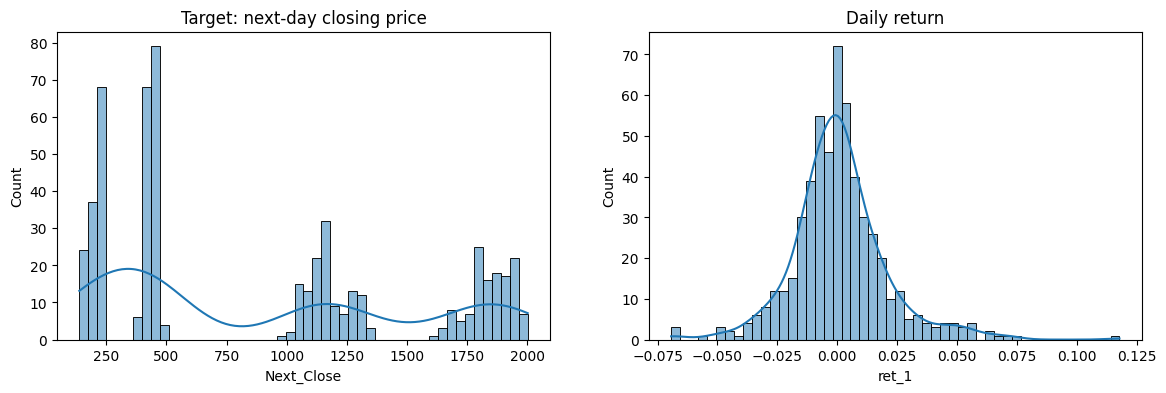

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(data['Next_Close'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Target: next-day closing price')
sns.histplot(data['ret_1'], bins=50, kde=True, ax=axes[1])
axes[1].set_title('Daily return')
plt.show()

<Axes: >

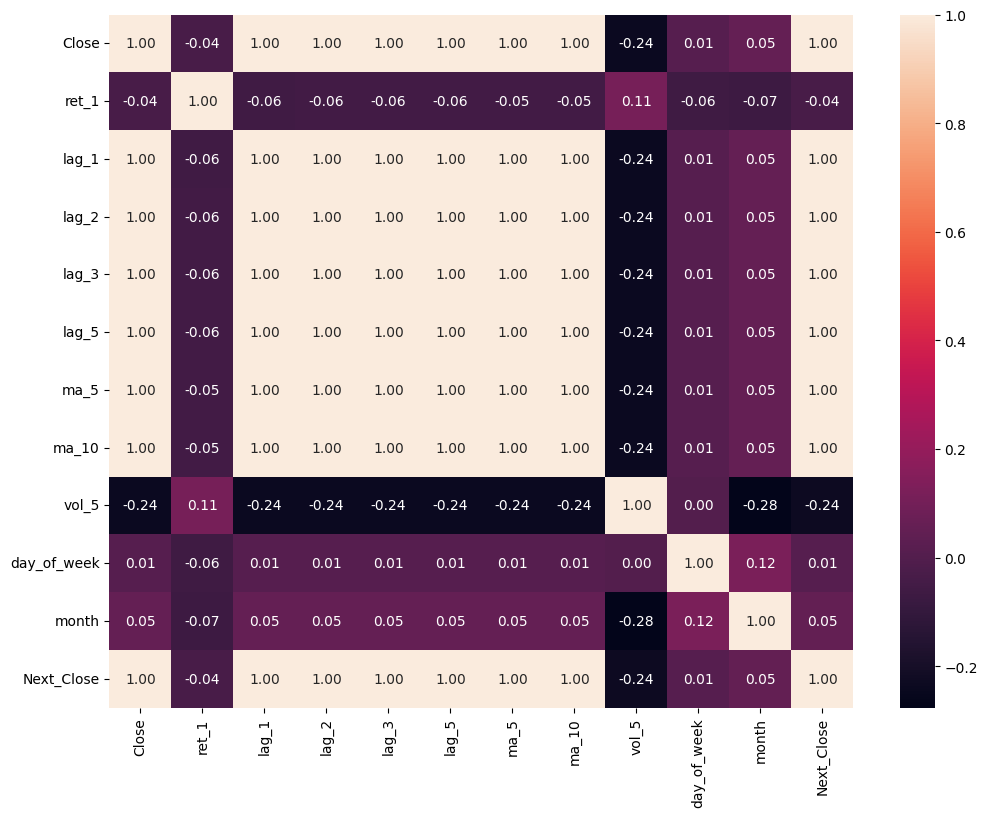

In [13]:
plt.figure(figsize=(12, 9))
sns.heatmap(data.corr(numeric_only=True), annot=True, fmt='.2f')

<Axes: xlabel='Stock', ylabel='Stock'>

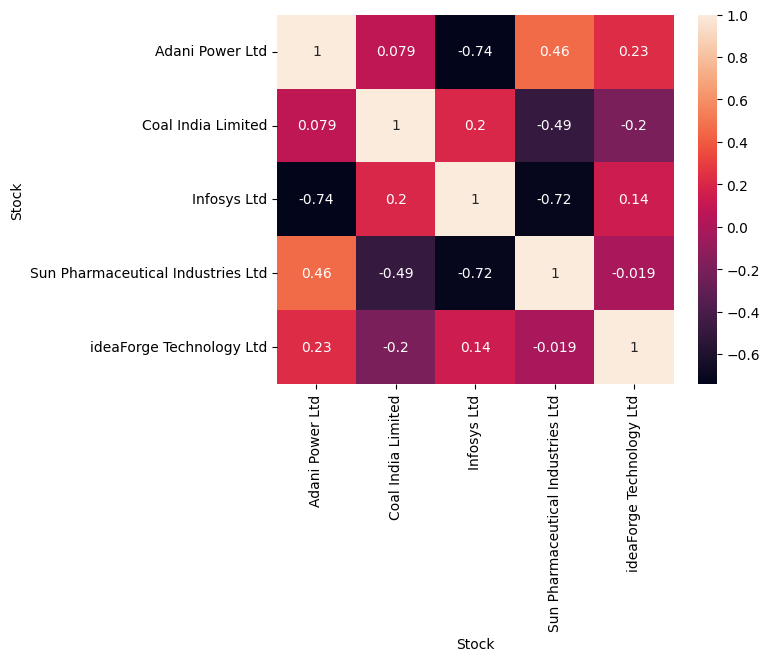

In [14]:
# how the stocks move together
sns.heatmap(df.pivot(index='Date', columns='Stock', values='Close').corr(), annot=True)

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Adani Power Ltd'),
  Text(1, 0, 'Coal India Limited'),
  Text(2, 0, 'Infosys Ltd'),
  Text(3, 0, 'Sun Pharmaceutical Industries Ltd'),
  Text(4, 0, 'ideaForge Technology Ltd')])

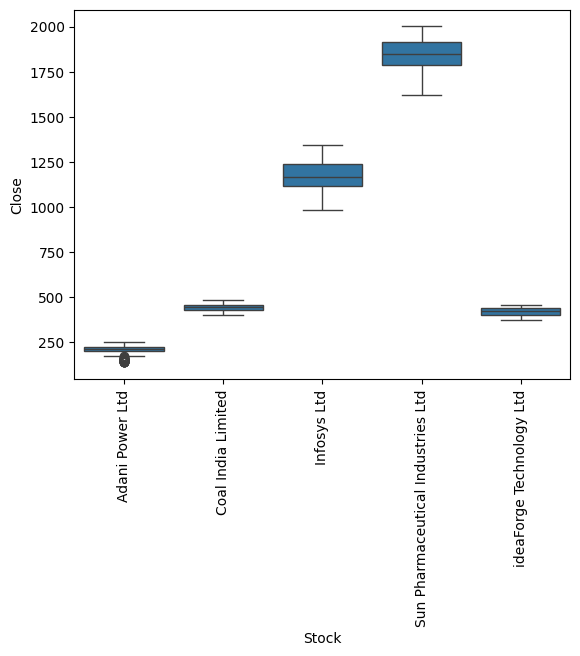

In [15]:
sns.boxplot(data=data, x='Stock', y='Close')
plt.xticks(rotation=90)

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Adani Power Ltd'),
  Text(1, 0, 'Coal India Limited'),
  Text(2, 0, 'Infosys Ltd'),
  Text(3, 0, 'Sun Pharmaceutical Industries Ltd'),
  Text(4, 0, 'ideaForge Technology Ltd')])

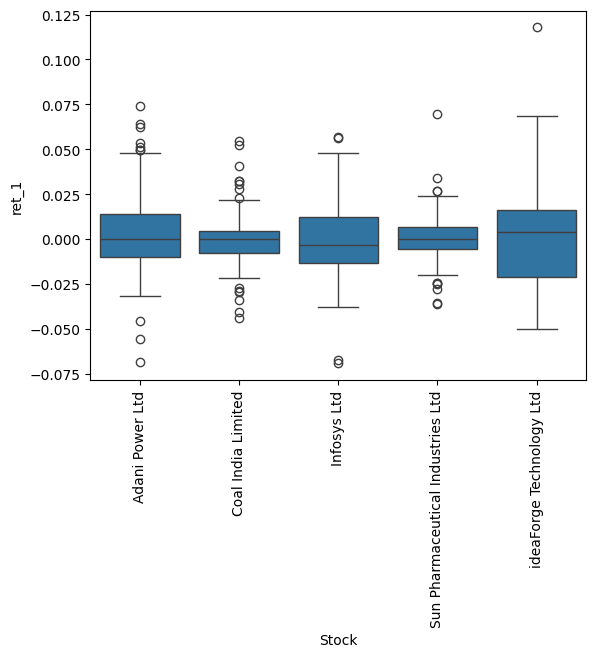

In [16]:
sns.boxplot(data=data, x='Stock', y='ret_1')
plt.xticks(rotation=90)

<Axes: xlabel='day_of_week', ylabel='ret_1'>

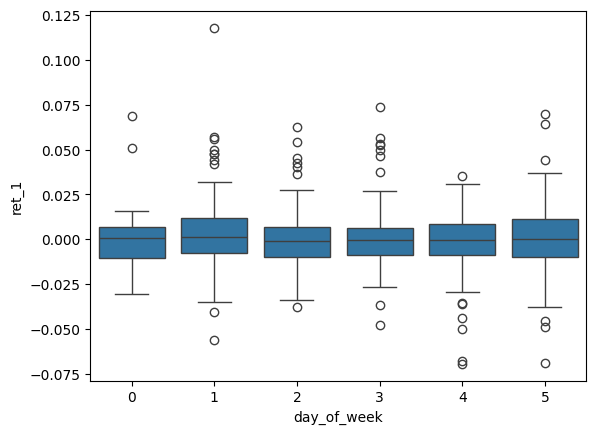

In [17]:
sns.boxplot(data=data, x='day_of_week', y='ret_1')

<Axes: xlabel='month', ylabel='ret_1'>

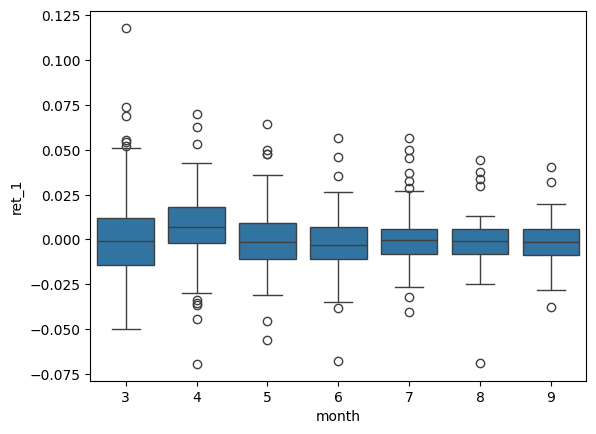

In [18]:
sns.boxplot(data=data, x='month', y='ret_1')

<Axes: xlabel='Close', ylabel='Next_Close'>

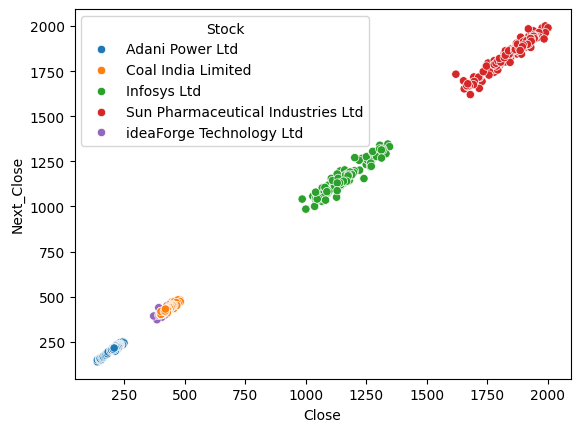

In [19]:
sns.scatterplot(data=data, x='Close', y='Next_Close', hue='Stock')

## 6. Split into X and y

In [20]:
X = data.drop(['Next_Close', 'Date', 'Next_Date'], axis=1)
y = data['Next_Close']

## 7. One-hot encoding

In [21]:
X_one_encoded = pd.get_dummies(X, columns=['Stock'], drop_first=True)

In [22]:

X_one_encoded = X_one_encoded.astype('float64')
X_one_encoded.head()

,Close,ret_1,lag_1,lag_2,lag_3,lag_5,ma_5,ma_10,vol_5,day_of_week,month,Stock_Coal India Limited,Stock_Infosys Ltd,Stock_Sun Pharmaceutical Industries Ltd,Stock_ideaForge Technology Ltd
0,137.97,-0.015274,140.11,141.34,140.54,144.05,140.854,142.031,0.012886,0.0,3.0,0.0,0.0,0.0,0.0
1,426.25,-0.010217,430.65,433.50,438.60,426.00,431.990,426.520,0.013535,0.0,3.0,1.0,0.0,0.0,0.0
2,1288.90,-0.008615,1300.10,1289.10,1290.10,1327.50,1288.740,1325.980,0.020308,0.0,3.0,0.0,1.0,0.0,0.0
3,1752.50,0.008923,1737.00,1785.70,1764.20,1732.30,1754.240,1738.280,0.017972,0.0,3.0,0.0,0.0,1.0,0.0
4,441.30,0.068523,413.00,424.60,409.90,409.45,419.540,416.485,0.037127,0.0,3.0,0.0,0.0,0.0,1.0


## 8. Label encoding

In [23]:
from sklearn.preprocessing import LabelEncoder
Xlable = X.copy()
columns = ['Stock']
for col in columns:
    le = LabelEncoder()
    Xlable[col] = le.fit_transform(Xlable[col])
Xlable.head()

,Stock,Close,ret_1,lag_1,lag_2,lag_3,lag_5,ma_5,ma_10,vol_5,day_of_week,month
0,0,137.97,-0.015274,140.11,141.34,140.54,144.05,140.854,142.031,0.012886,0,3
1,1,426.25,-0.010217,430.65,433.50,438.60,426.00,431.990,426.520,0.013535,0,3
2,2,1288.90,-0.008615,1300.10,1289.10,1290.10,1327.50,1288.740,1325.980,0.020308,0,3
3,3,1752.50,0.008923,1737.00,1785.70,1764.20,1732.30,1754.240,1738.280,0.017972,0,3
4,4,441.30,0.068523,413.00,424.60,409.90,409.45,419.540,416.485,0.037127,0,3


## 9. Scaling

In [24]:
from sklearn.preprocessing import StandardScaler

In [25]:
numerical_cols = ['Close', 'ret_1', 'lag_1', 'lag_2', 'lag_3', 'lag_5', 'ma_5', 'ma_10', 'vol_5', 'day_of_week', 'month']
scaler = StandardScaler()
X_one_encoded[numerical_cols] = scaler.fit_transform(X_one_encoded[numerical_cols])

In [26]:
columns_to_scale = list(Xlable.columns)
scaler2 = StandardScaler()      # separate scaler so `scaler` above stays valid for forecasting later
Xlable[columns_to_scale] = scaler2.fit_transform(Xlable[columns_to_scale])

## 10. Train / test split

In [27]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X_one_encoded, y, test_size=0.33, shuffle=False)
print('train:', X_train.shape, ' test:', X_test.shape)
print('train dates up to', data.loc[X_train.index, 'Date'].max().date(), '| test dates from', data.loc[X_test.index, 'Date'].min().date())

train: (364, 15)  test: (180, 15)
train dates up to 2026-07-07 | test dates from 2026-07-08


## 11. Model 1: Linear Regression (one-hot encoded)

In [29]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [30]:
y_pred = model.predict(X_test)

In [31]:
r2 = r2_score(y_test, y_pred)
r2

0.999463500027344

In [32]:
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
adjusted_r2

0.9994144299078938

In [33]:
# Extra: error in rupees, and a naive baseline ("tomorrow's price = today's price") to see if the model adds anything
naive_pred = X.loc[y_test.index, 'Close']          # X still holds the unscaled prices

print('Model  MAE :', round(mean_absolute_error(y_test, y_pred), 2), '  RMSE:', round(np.sqrt(mean_squared_error(y_test, y_pred)), 2), '  R2:', round(r2, 4))
print('Naive  MAE :', round(mean_absolute_error(y_test, naive_pred), 2), '  RMSE:', round(np.sqrt(mean_squared_error(y_test, naive_pred)), 2), '  R2:', round(r2_score(y_test, naive_pred), 4))

Model  MAE : 9.82   RMSE: 15.67   R2: 0.9995
Naive  MAE : 9.45   RMSE: 15.36   R2: 0.9995


In [34]:
# Per-stock average % error on the test period
res = pd.DataFrame({'Stock': X.loc[y_test.index, 'Stock'], 'Actual': y_test, 'Model': y_pred, 'Naive': naive_pred})
res['Model_%err'] = (res['Actual'] - res['Model']).abs() / res['Actual'] * 100
res['Naive_%err'] = (res['Actual'] - res['Naive']).abs() / res['Actual'] * 100
res.groupby('Stock')[['Model_%err', 'Naive_%err']].mean().round(2)

,Model_%err,Naive_%err
Stock,,
Adani Power Ltd,1.36,1.38
Coal India Limited,0.77,0.68
Infosys Ltd,1.53,1.51
Sun Pharmaceutical Industries Ltd,0.84,0.79


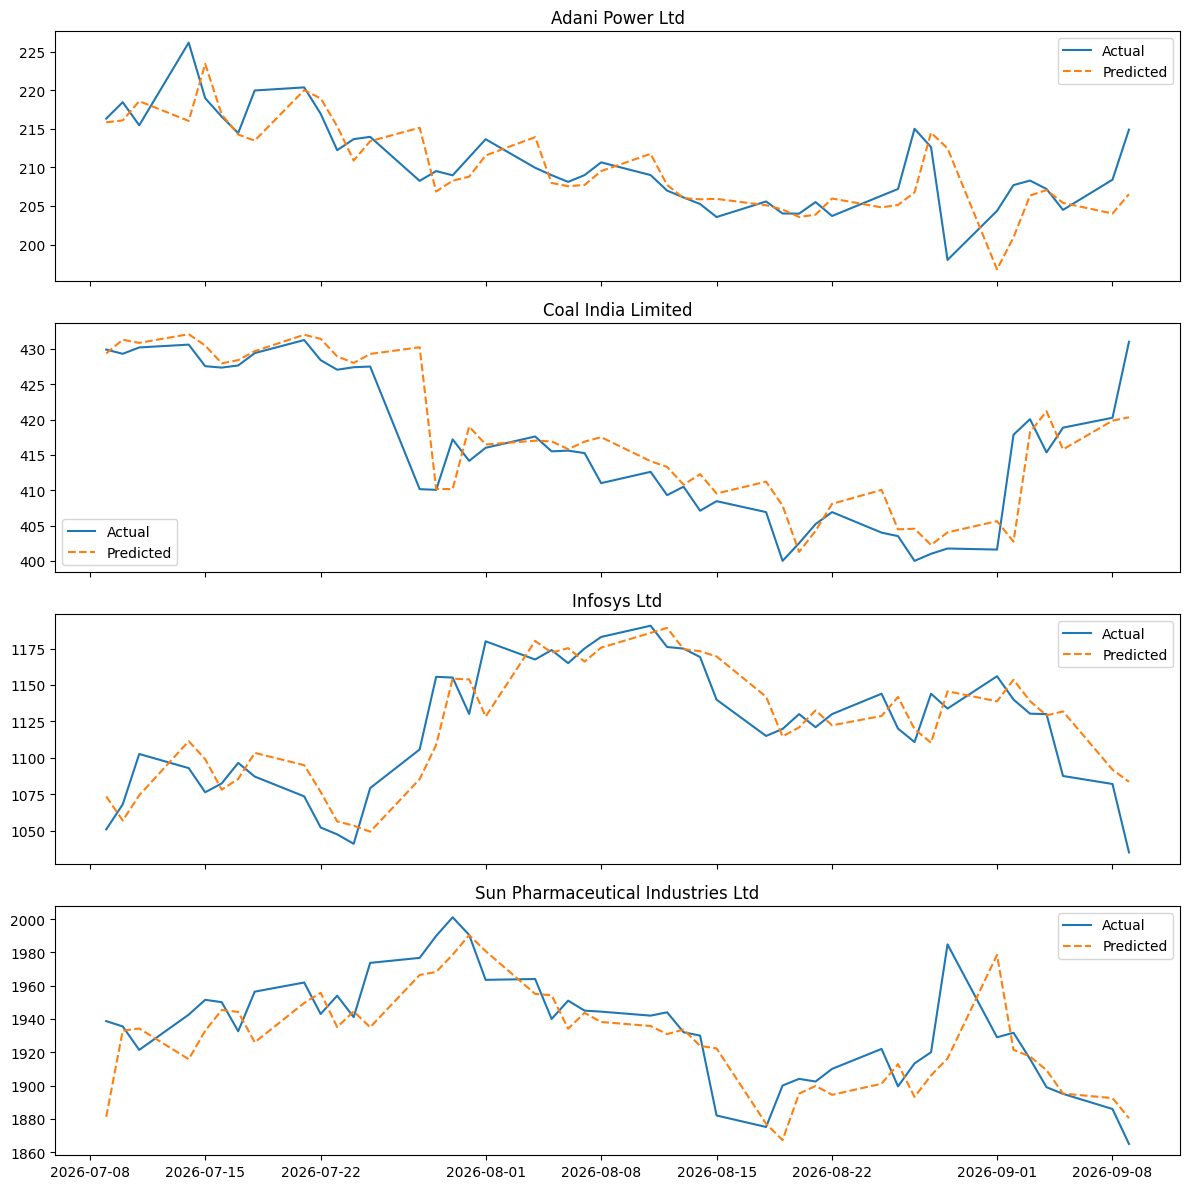

In [35]:
# Actual vs predicted on the test period
fig, axes = plt.subplots(len(res['Stock'].unique()), 1, figsize=(12, 3 * len(res['Stock'].unique())), sharex=True)
for ax, (s, g) in zip(axes, res.groupby('Stock')):
    d = data.loc[g.index, 'Next_Date']
    ax.plot(d, g['Actual'], label='Actual')
    ax.plot(d, g['Model'], '--', label='Predicted')
    ax.set_title(s)
    ax.legend()
plt.tight_layout()
plt.show()

## 12. Model 2: Linear Regression (label encoded)

In [36]:
X_train, X_test, y_train, y_test = train_test_split(Xlable, y, test_size=0.33, shuffle=False)

In [37]:
model2 = LinearRegression()
model2.fit(X_train, y_train)

LinearRegression()

In [38]:
y_pred = model2.predict(X_test)

In [39]:
r2 = r2_score(y_test, y_pred)
r2

0.9994762721377622

In [40]:
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
adjusted_r2

0.9994386389979607

## 13. Forecast future prices for each stock

Uses Model 1 (one-hot). The model predicts **one day ahead**, so to go further we predict a day, add it to the history, rebuild the features and repeat (recursive forecast). Errors compound with each step, so treat later days as rough trend estimates, not exact prices.

In [41]:
FORECAST_DAYS = 30     # trading days ahead (Mon-Fri; market holidays are not removed)
MIN_ROWS = 60          # stocks with less history than this are skipped (lower it to force a forecast)

def encode_for_model(row):
    """Turn one feature row into the exact format Model 1 was trained on (one-hot + scaled)."""
    x = pd.DataFrame(0.0, index=[0], columns=X_one_encoded.columns)
    for c in numerical_cols:
        x[c] = float(row[c])
    dummy = f"Stock_{row['Stock']}"
    if dummy in x.columns:             # the first stock (dropped by drop_first) is all zeros
        x[dummy] = 1.0
    x[numerical_cols] = scaler.transform(x[numerical_cols])
    return x

latest_date = df['Date'].max()
forecasts, summary = [], []

for stock, g in df.groupby('Stock'):
    hist = g[['Date', 'Stock', 'Close']].sort_values('Date').reset_index(drop=True)

    if len(hist) < MIN_ROWS:
        print(f"Skipped {stock}: only {len(hist)} rows, data ends {hist['Date'].max().date()} (latest in file: {latest_date.date()}).")
        continue

    future_dates = pd.bdate_range(hist['Date'].iloc[-1] + pd.Timedelta(days=1), periods=FORECAST_DAYS)
    last_close = hist['Close'].iloc[-1]

    for d in future_dates:
        last_row = make_features(hist).iloc[-1]
        pred = model.predict(encode_for_model(last_row))[0]
        hist = pd.concat([hist, pd.DataFrame({'Date': [d], 'Stock': [stock], 'Close': [pred]})], ignore_index=True)
        forecasts.append({'Date': d, 'Stock': stock, 'Predicted_Close': round(float(pred), 2)})

    summary.append({
        'Stock': stock,
        'Last actual date': g['Date'].max().date(),
        'Last actual close': last_close,
        f'Forecast close (day {FORECAST_DAYS})': round(float(pred), 2),
        'Change %': round((pred / last_close - 1) * 100, 2),
    })

forecast_df = pd.DataFrame(forecasts)
pd.DataFrame(summary)

Skipped ideaForge Technology Ltd: only 38 rows, data ends 2026-04-16 (latest in file: 2026-09-09).


,Stock,Last actual date,Last actual close,Forecast close (day 30),Change %
0,Adani Power Ltd,2026-09-09,214.9,191.10,-11.07
1,Coal India Limited,2026-09-09,431.0,428.12,-0.67
2,Infosys Ltd,2026-09-09,1035.0,1128.39,9.02
3,Sun Pharmaceutical Industries Ltd,2026-09-09,1864.9,1793.05,-3.85


In [42]:
forecast_df.groupby('Stock').head(5)      # first 5 forecast days per stock

,Date,Stock,Predicted_Close
0,2026-09-10,Adani Power Ltd,213.73
1,2026-09-11,Adani Power Ltd,212.75
2,2026-09-14,Adani Power Ltd,211.73
3,2026-09-15,Adani Power Ltd,208.75
4,2026-09-16,Adani Power Ltd,206.80
30,2026-09-10,Coal India Limited,432.03
31,2026-09-11,Coal India Limited,433.24
32,2026-09-14,Coal India Limited,434.00
33,2026-09-15,Coal India Limited,432.55
34,2026-09-16,Coal India Limited,431.86


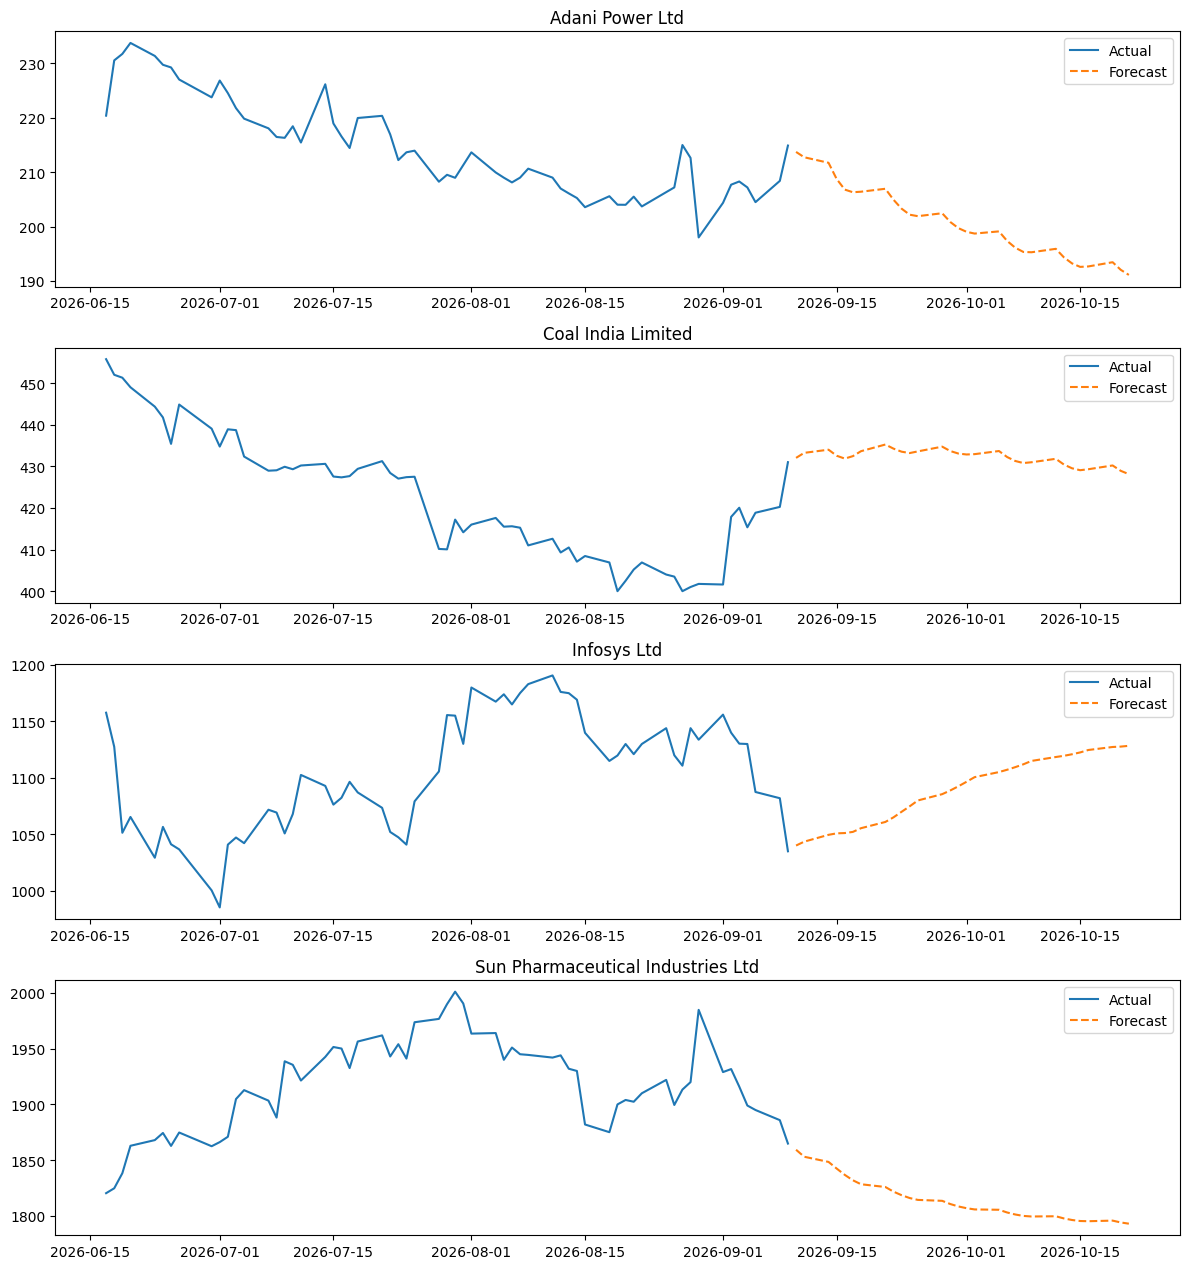

In [43]:
# Last 60 actual days + forecast
stocks_fc = forecast_df['Stock'].unique()
fig, axes = plt.subplots(len(stocks_fc), 1, figsize=(12, 3.2 * len(stocks_fc)))
for ax, s in zip(np.atleast_1d(axes), stocks_fc):
    h = df[df['Stock'] == s].tail(60)
    f = forecast_df[forecast_df['Stock'] == s]
    ax.plot(h['Date'], h['Close'], label='Actual')
    ax.plot(f['Date'], f['Predicted_Close'], '--', label='Forecast')
    ax.set_title(s)
    ax.legend()
plt.tight_layout()
plt.show()

## 14. Save the forecasts

In [44]:
forecast_df.to_csv('stock_forecasts.csv', index=False)

try:
    from google.colab import files
    files.download('stock_forecasts.csv')
except ImportError:
    print('Saved stock_forecasts.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Notes**
- A high R² here is expected: prices are on a very different scale per stock, and "tomorrow ≈ today" already explains most of the variance. Compare the model's MAE / % error with the naive baseline in step 11, not R² alone.
- Linear Regression forecasts look like smooth curves that drift back toward recent averages; real prices are noisier and can break from any trend. This is a learning project, not investment advice.